# L6. Lab: Robot Memory Agent, and Wrap-Up

Same `EdgeShard`, a different body: a robot that patrols and remembers what it sees. This lab bounds that memory with a budget, so hazards persist while stale noise fades.

## 1. The world and the patrol

In [1]:
from helper import ROBOT_WORLD
for (x, y), (cls, conf, hazard) in ROBOT_WORLD.items():
    flag = "HAZARD" if hazard else "object"
    print(f"({x},{y})  {flag:>6}  confidence={conf:.2f}  {cls}")

(2,2)  HAZARD  confidence=0.92  wet floor spill
(6,4)  HAZARD  confidence=0.88  loose cable
(3,1)  object  confidence=0.60  cardboard box
(7,5)  object  confidence=0.70  doorway
(1,4)  object  confidence=0.55  chair
(5,2)  object  confidence=0.58  shelf
(4,5)  object  confidence=0.40  puddle


## 2. Patrol under a memory budget

In [2]:
from helper import robot_simulate

BUDGET = 8
frames, sizes_capped, sizes_uncapped, shard = robot_simulate(
    budget=BUDGET)
print(f"Observations made: {sizes_uncapped[-1]}   |   "
     f"Memories kept: {sizes_capped[-1]}")

Observations made: 25   |   Memories kept: 8


## 3. Money output: memory over time

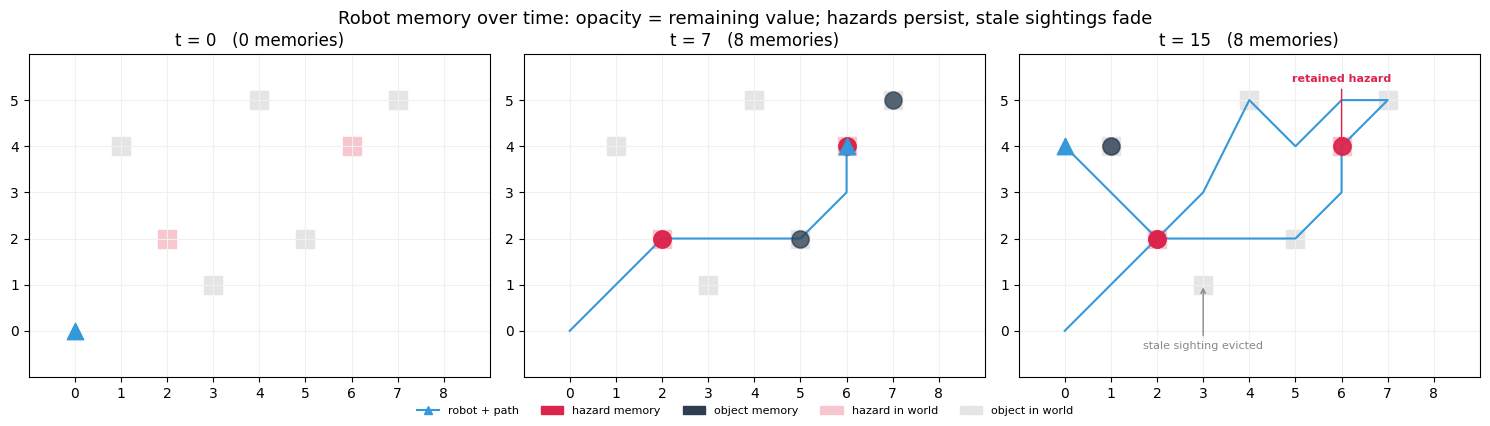

In [3]:
from helper import grid_frames
grid_frames(frames)

## 4. Money output: the budget keeps the shard bounded

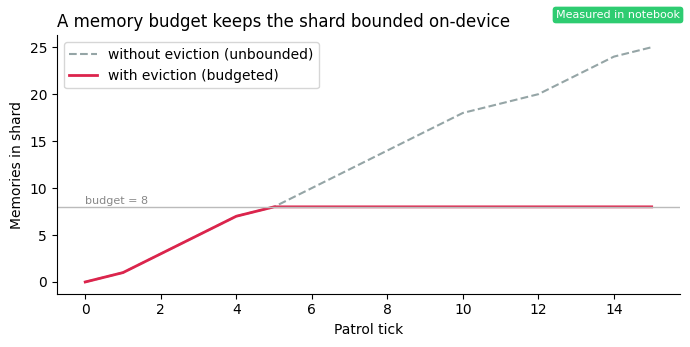

In [4]:
from helper import decay_chart
decay_chart(sizes_capped, sizes_uncapped, BUDGET)

## 5. Ask the robot two things

In [5]:
from qdrant_edge import UpdateOperation, PayloadSchemaType

# Index the fields we filter on (spatial, time, and the hazard flag).
for field in ["x", "y", "timestamp", "is_hazard"]:
    shard.update(UpdateOperation.create_field_index(
        field, PayloadSchemaType.Integer))
shard.optimize()
print("Indexed x, y, timestamp, is_hazard")

Indexed x, y, timestamp, is_hazard


In [6]:
from helper import (search_memories, embed_query, all_of,
                   match, numeric, distinct_objects)

# Q1: "have I seen a hazard near the entrance?"
#  -> is_hazard = 1 AND x < 4
# The robot re-sees things, so distinct_objects collapses
# repeat sightings.
print('Q1: "any hazard near the entrance?"   '
     'filter: is_hazard = 1 AND x < 4')
q1_filter = all_of(match("is_hazard", 1), numeric("x", lt=4))
hits = search_memories(
    shard, "text", embed_query("dangerous hazard on the floor"),
    limit=8, query_filter=q1_filter)
for h in distinct_objects(hits):
    p = h.payload
    print(f"  {h.score:.3f}  {p['object_class']} "
         f"at ({p['x']},{p['y']})  hazard={bool(p['is_hazard'])}")

Q1: "any hazard near the entrance?"   filter: is_hazard = 1 AND x < 4
  0.701  wet floor spill at (2,2)  hazard=True


In [7]:
# Q2: "what did I see near the door, recently?"
#  -> x >= 6 AND timestamp in the last 10 ticks
last_tick = len(sizes_capped) - 1
recent = last_tick - 9  # our stand-in for "the last 10 minutes"
print(f'Q2: "near the door, recently?"   '
     f'filter: x >= 6 AND timestamp >= {recent}')
q2_filter = all_of(
    numeric("x", gte=6), numeric("timestamp", gte=recent))
hits = search_memories(
    shard, "text", embed_query("cable or wire hazard by the doorway"),
    limit=8, query_filter=q2_filter)
for h in distinct_objects(hits):
    p = h.payload
    print(f"  {h.score:.3f}  {p['object_class']} "
         f"at ({p['x']},{p['y']})  t={p['timestamp']}")

Q2: "near the door, recently?"   filter: x >= 6 AND timestamp >= 6
  0.578  loose cable at (6,4)  t=10


## 6. Money output: ask the device what it knows

In [8]:
from pathlib import Path
from helper import (reopen_shard, gather_device_knowledge,
                   knowledge_dashboard, no_network)
from IPython.display import display

# The phone assistant's shard from L5. Reopen it in this
# workspace (run L5 first).
phone = (reopen_shard("../L5/day_shard")
        if Path("../L5/day_shard").exists() else None)

with no_network():
    stats = gather_device_knowledge(
        shard, phone, evicted=sizes_uncapped[-1] - sizes_capped[-1])
display(knowledge_dashboard(stats))

⚠ Network disabled for this cell


In [9]:
from helper import cleanup
cleanup(shard, "./robot_shard")
if phone is not None:
    cleanup(phone, "../L5/day_shard")
print("Cleaned up")

Cleaned up
